6. In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

(a) Perform polynomial regression to predict wage using age. Use
cross-validation to select the optimal degree d for the polyno-
mial. What degree was chosen, and how does this compare to
the results of hypothesis testing using ANOVA? Make a plot of
the resulting polynomial fit to the data.

Best degree from CV: 8


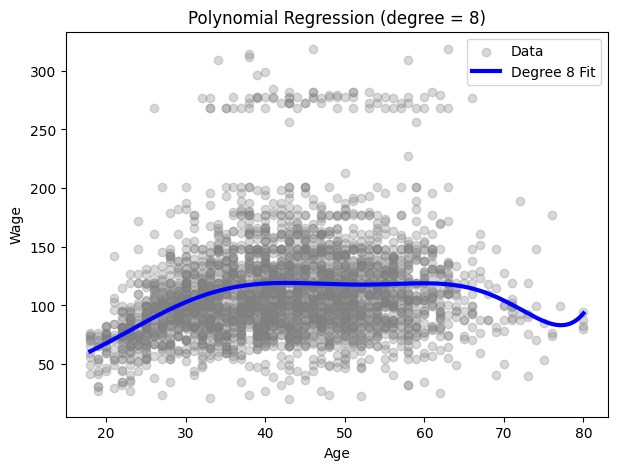

   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

wage = pd.read_csv("Wage.csv")
X = wage[["age"]].values
y = wage["wage"].values

# Cross-validation
degrees = range(1, 11)
cv_errors = []
kf = KFold(n_splits=10, shuffle=True, random_state=1)

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf)
    cv_errors.append(-scores.mean())

best_degree = degrees[np.argmin(cv_errors)]
print("Best degree from CV:", best_degree)

# best model
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("linreg", LinearRegression())
])
best_model.fit(X, y)

age_grid = np.linspace(wage["age"].min(), wage["age"].max(), 200).reshape(-1, 1)
pred = best_model.predict(age_grid)

plt.figure(figsize=(7, 5))
plt.scatter(wage["age"], wage["wage"], alpha=0.3, color="gray", label="Data")
plt.plot(age_grid, pred, color="blue", linewidth=3, label=f"Degree {best_degree} Fit")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Regression (degree = {best_degree})")
plt.legend()
plt.show()

# ANOVA
import statsmodels.formula.api as smf
import statsmodels.api as sm

wage["age2"] = wage["age"] ** 2
wage["age3"] = wage["age"] ** 3
wage["age4"] = wage["age"] ** 4
wage["age5"] = wage["age"] ** 5

m1 = smf.ols("wage ~ age", data=wage).fit()
m2 = smf.ols("wage ~ age + age2", data=wage).fit()
m3 = smf.ols("wage ~ age + age2 + age3", data=wage).fit()
m4 = smf.ols("wage ~ age + age2 + age3 + age4", data=wage).fit()
m5 = smf.ols("wage ~ age + age2 + age3 + age4 + age5", data=wage).fit()

anova_res = sm.stats.anova_lm(m1, m2, m3, m4, m5)
print(anova_res)


(b) Fit a step function to predict wage using age, and perform cross-
validation to choose the optimal number of cuts. Make a plot of
the fit obtained.

Best number of cuts from CV: 8


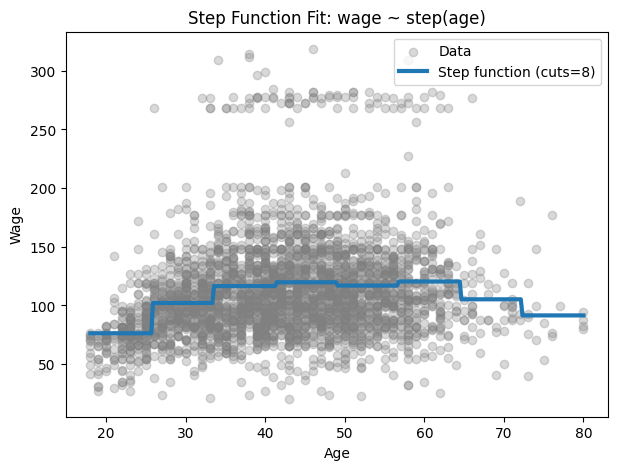

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

cuts_list = range(2, 11)
cv_errors_step = []

kf = KFold(n_splits=10, shuffle=True, random_state=1)

for k in cuts_list:
    model_step = Pipeline([
        ("bins", KBinsDiscretizer(n_bins=k, encode="onehot-dense",
                                  strategy="uniform")),
        ("linreg", LinearRegression())
    ])

    scores = cross_val_score(
        model_step, X, y,
        scoring="neg_mean_squared_error",
        cv=kf
    )
    cv_errors_step.append(-scores.mean())

cv_errors_step = np.array(cv_errors_step)
best_cuts = cuts_list[np.argmin(cv_errors_step)]
print("Best number of cuts from CV:", best_cuts)


best_step_model = Pipeline([
    ("bins", KBinsDiscretizer(n_bins=best_cuts, encode="onehot-dense",
                              strategy="uniform")),
    ("linreg", LinearRegression())
])
best_step_model.fit(X, y)

age_grid = np.linspace(wage["age"].min(),
                       wage["age"].max(), 300).reshape(-1, 1)
wage_pred_step = best_step_model.predict(age_grid)

plt.figure(figsize=(7, 5))
plt.scatter(wage["age"], wage["wage"], alpha=0.3, color="gray", label="Data")
plt.plot(age_grid, wage_pred_step, linewidth=3, label=f"Step function (cuts={best_cuts})")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Step Function Fit: wage ~ step(age)")
plt.legend()
plt.show()
